## Complete model

In [1]:
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt
import rasterio
from src2.FDrule import FDrule
np.random.seed(10)

1
# -0.08355775171904134 24 2.021484375
# -0.08355775171904134 18 1.8005493825845176
1
# -0.47576274112025496 77 0.5067978896103894
# -0.47576274112025496 67 0.48825303783316043
1
# -0.3497276834457405 150 0.2625
# -0.3497276834457405 31 1.0552565656394113
1
# -0.43189841599881224 78 0.5048076923076923
# -0.43189841599881224 49 0.6676112966290153
1
# -0.36302583478452366 79 0.4978614517405065
# -0.36302583478452366 49 0.6686293902302849


<Figure size 640x480 with 0 Axes>

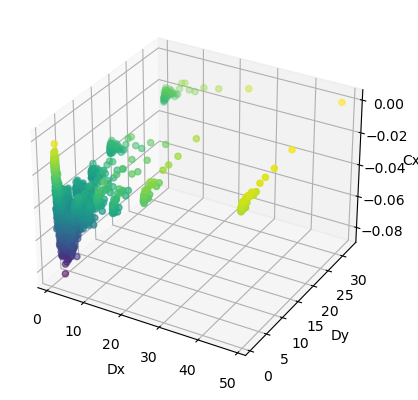

<Figure size 640x480 with 0 Axes>

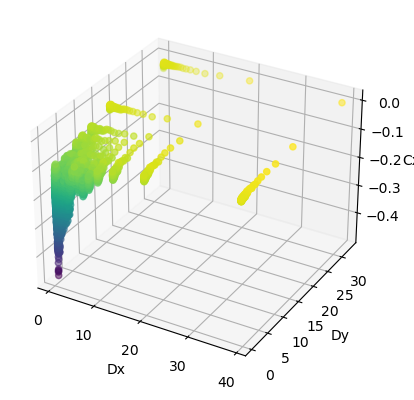

<Figure size 640x480 with 0 Axes>

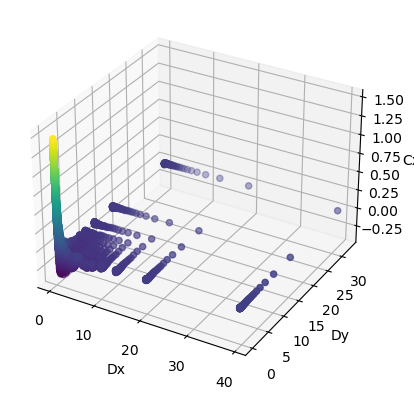

<Figure size 640x480 with 0 Axes>

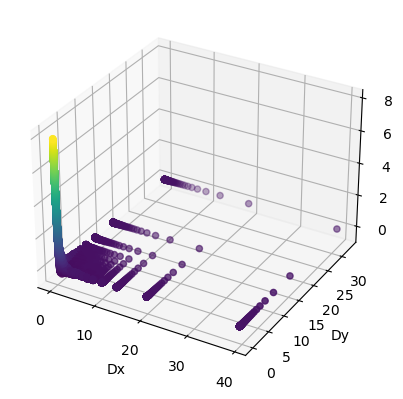

<Figure size 640x480 with 0 Axes>

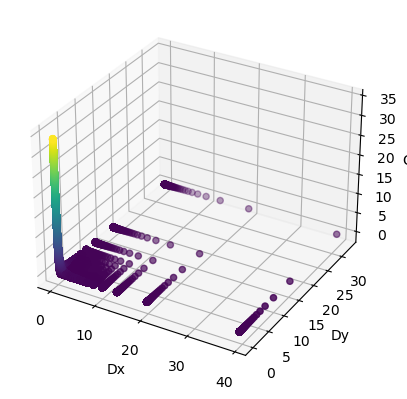

In [2]:
accu=[]
nsi=[]
pres=[]
recall=[]

for i in range(6,11):
    nside=2**i
    nsi.append(nside)
    df=pd.read_csv('./database/Australia.csv')
    Lon=df['Longitude in degrees'].to_numpy()
    Lat=df['Latitude in degrees'].to_numpy()
    power=df['EIRP'].to_numpy()
    frequency=df['Frequency(MHz)'].to_numpy()

    trainpix=hp.ang2pix(nside,Lon,Lat,lonlat=True)

    new_pix=np.random.choice(trainpix,size=int(0.1*len(Lon)))

    int(0.1*len(Lon))

    Tx_num_128=np.zeros(hp.nside2npix(nside))
    for pix in trainpix:
        Tx_num_128[pix]+=1

    ## Start 2d prob model now

    smallon,smallat=hp.pix2ang(nside,new_pix,lonlat=True)
    smallon[smallon>180]-=360

    data=np.column_stack((smallon,smallat))

    minres=hp.nside2resol(nside,arcmin=True)

    minres=minres/60

    minres

    ## Best bin width (Shimazaki et al.)

    from numpy import arange, argmin, sum, mean, var, size, zeros, where, histogram

    x = smallon 
    y = smallat  

    x_max = max(x)
    x_min = min(x)

    y_max = max(y)
    y_min = min(y)

    Nx_MIN = 1  # Minimum number of bins in x (integer)
    Nx_MAX = int((x_max-x_min)/minres)  # Maximum number of bins in x (integer)

    Ny_MIN = 1  # Minimum number of bins in y (integer)
    Ny_MAX = int((y_max-y_min)/minres)  # Maximum number of bins in y (integer)

    Nx = arange(Nx_MIN, Nx_MAX)  # #of Bins
    Ny = arange(Ny_MIN, Ny_MAX)  # #of Bins

    Dx = (x_max - x_min) / Nx  # Bin size vector
    Dy = (y_max - y_min) / Ny  # Bin size vector

    Dxy = []
    for i in Dx:  # Bin size vector
        a = []
        for j in Dy:  # Bin size vector
            a.append((i, j))
        Dxy.append(a)
    Dxy = np.array(Dxy, dtype=[('x', float), ('y', float)])  # matrix of bin size vector

    Cxy = zeros(np.shape(Dxy))

    Cxy__Dxy_plot = []  # save data to plot in scatterplot x,y,z

    # Computation of the cost function to x and y
    for i in range(size(Nx)):
        for j in range(size(Ny)):
            ki = np.histogram2d(x, y, bins=(Nx[i], Ny[j]))
            ki = ki[0]  # The mean and the variance are simply computed from the event counts in all the bins of the 2-dimensional histogram.
            k = mean(ki)  # Mean of event count
            v = var(ki)  # Variance of event count
            Cxy[i, j] = (2 * k - v) / ((Dxy[i, j][0] * Dxy[i, j][1]) ** 2)  # The cost Function

            # (Cxy      , Dx          ,  Dy)
            Cxy__Dxy_plot.append((Cxy[i, j], Dxy[i, j][0], Dxy[i, j][1]))  # Save result of cost function to scatterplot

    Cxy__Dxy_plot = np.array(Cxy__Dxy_plot, dtype=[('Cxy', float), ('Dx', float), ('Dy', float)])  # Save result of cost function to scatterplot

    # Optimal Bin Size Selection

    # combination of i and j that produces the minimum cost function
    idx_min_Cxy = np.where(Cxy == np.min(Cxy))  # get the index of the min Cxy

    Cxymin = Cxy[idx_min_Cxy[0][0], idx_min_Cxy[1][0]]  # value of the min Cxy

    print(sum(Cxy == Cxymin))  # check if there is only one min value

    optDxy = Dxy[idx_min_Cxy[0][0], idx_min_Cxy[1][0]]  # get the bins size pairs that produces the minimum cost function

    optDx = optDxy[0]
    optDy = optDxy[1]

    idx_Nx = idx_min_Cxy[0][0]  # get the index in x that produces the minimum cost function
    idx_Ny = idx_min_Cxy[1][0]  # get the index in y that produces the minimum cost function

    print('#', Cxymin, Nx[idx_Nx], optDx)
    print('#', Cxymin, Ny[idx_Ny], optDy)

    # PLOTS

    # plot histogram2d
    fig = plt.figure()
    H, xedges, yedges = np.histogram2d(x, y, bins=[Nx[idx_Nx], Ny[idx_Ny]])
    Hmasked = np.ma.masked_where(H == 0, H)

#     plot scatterplot3d to Dx,Dy and Cxy
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = Cxy__Dxy_plot['Dx']
    y = Cxy__Dxy_plot['Dy']
    z = Cxy__Dxy_plot['Cxy']
    ax.scatter(x, y, z, c=z, marker='o')

    ax.set_xlabel('Dx')
    ax.set_ylabel('Dy')
    ax.set_zlabel('Cxy')
    plt.draw()



    ### from mpl_toolkits.axes_grid1 import make_axes_locatable
    np.random.seed(42)


    x, y = data.T
    BIN_COUNT1 = Nx[idx_Nx]
    BIN_COUNT2=Ny[idx_Ny]

    hist, bins= np.histogramdd(data,bins=(BIN_COUNT1,BIN_COUNT2),density=True)
    x_bins=bins[0]
    y_bins=bins[1]
    x_bin_midpoints = (x_bins[:-1] + x_bins[1:])/2
    y_bin_midpoints = (y_bins[:-1] + y_bins[1:])/2

    cdf = np.cumsum(hist.flatten())
    cdf = cdf / cdf[-1]

    # values = np.random.rand(finval)
    # value_bins = np.searchsorted(cdf, values)
    # x_idx, y_idx = np.unravel_index(value_bins,
    #                                 (len(x_bin_midpoints),
    #                                  len(y_bin_midpoints)))
    # random_from_cdf = np.column_stack((x_bin_midpoints[x_idx],
    #                                    y_bin_midpoints[y_idx]))
    # new_x, new_y = random_from_cdf.T


    (max(x)-min(x))/BIN_COUNT1


    hist=hist.reshape(BIN_COUNT1,BIN_COUNT2) # reshape back for interpolation

    from scipy.interpolate import RegularGridInterpolator
    x1=x_bins[:-1]
    y1=y_bins[:-1]
    V=hist

    fn=RegularGridInterpolator((x1,y1),V,bounds_error=False,fill_value=0)


    # Open the GeoTIFF file
    src = rasterio.open('/home/saurabhs/Documents/Yogen_starfire/5kRasters/Australia_raster.tif')

    # Read the raster data as a numpy array
    data = src.read(1)  

    # Find pixels with non-zero values
    non_zero_pixels = np.where(data != 0)

    # Get the coordinates of non zero pixels
    templat=[]
    templon=[]
    for y, x in zip(*non_zero_pixels):
        lonval, latval = src.xy(y, x)  # Get the longitude and latitude of the pixel
        templat.append(latval)
        templon.append(lonval)


    # country raster 
    # Making a mask for generated data
    temppix=hp.ang2pix(nside,templon,templat,lonlat=True)
    template=np.zeros(hp.nside2npix(nside))
    for pi in temppix:
        template[pi]+=1
    template=np.where(template != 0, 1, 0)

    # plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper_images/Country_shp.pdf',dpi=600)

    pop_pix=np.argwhere(template) # obtain non zero pix aka country pix
    pop_pix=np.sort(pop_pix)
    allon,allat=hp.pix2ang(nside,pop_pix,lonlat=True)        
    allon[allon>180]-=360
    allon=allon.reshape(allon.shape[0])
    allat=allat.reshape(allat.shape[0])

    pop_pix.shape

    prob_vals=[] # obtain probabilty values for each pixel of the country (represented by allon and allat)
    for i in range(len(allat)):
        a=allon[i]
        b=allat[i]
        prob_vals.append(fn([a,b]))
    prob_vals=np.array(prob_vals)
    prob_vals=prob_vals.reshape(prob_vals.shape[0]) 

    prob_vals=prob_vals/np.sum(prob_vals) # normalize the PDF for generating synth data

    prob_pix=hp.ang2pix(nside,allon,allat,lonlat=True)
    prob_healpix=np.zeros(hp.nside2npix(nside))
    for index,p in enumerate(prob_pix):
        prob_healpix[p]+=(prob_vals[index])

    # plt.savefig('/home/pratush/Yogen_STARFIRE/STARFIRE_paper images/new_Txpow',dpi=600)


    pop_pix=pop_pix.reshape(pop_pix.shape[0]) 
    genpix=np.random.choice(pop_pix,size=len(Lon),p=prob_vals)

    genlon,genlat=hp.pix2ang(nside,genpix,lonlat=True)
    genlon[genlon>180]-=360

    newdf=pd.DataFrame({'lon':genlon,'lat':genlat})
    # newdf.to_csv('/home/pratush/Documents/auscheck.csv')

    binary_original=np.zeros(hp.nside2npix(nside))

    for i in trainpix:
        binary_original[i]+=1
    binary_original=np.where(binary_original != 0, 1, 0)




    binary_synth=np.zeros(hp.nside2npix(nside))


    for i in genpix:
        binary_synth[i]+=1
    binary_synth=np.where(binary_synth != 0, 1, 0)




    binary_original=binary_original[pop_pix]
    binary_synth=binary_synth[pop_pix]
    orgnonz=np.array(np.nonzero(binary_original)[0])
    orgzero=np.array(np.where(binary_original==0))

    # True positives: binary_synth[orgnonz]=1
    # True negatives: binary_synth[~orgnonz]=0
    # False positives: binary_synth[~orgnonz]=1
    # False negatives: binary_synth[orgnonz]=0

    TP=np.size(np.nonzero(binary_synth[orgnonz])[0])
    TN=np.size(np.where(binary_synth[orgzero]==0)[0])
    FP=np.size(np.where(binary_synth[orgzero]==1)[0])
    FN=np.size(np.where(binary_synth[orgnonz]==0)[0])

    accu.append((TP+TN)/(TP+TN+FP+FN))
    pres.append(TP/(TP+FP))
    recall.append(TP/(TP+FN))
    
#     print(accuracy,precision,recall)

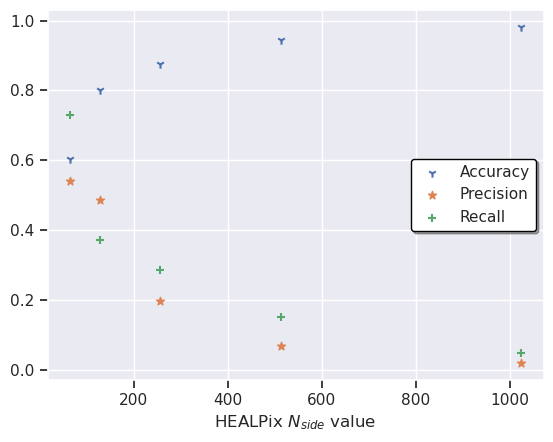

In [3]:
import seaborn as sns
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True})

plt.scatter(nsi,accu,marker='1',label='Accuracy')
plt.scatter(nsi,pres,marker='*',label='Precision')
plt.scatter(nsi,recall,marker='+',label='Recall')
plt.xlabel('HEALPix $N_{side}$ value')
# plt.xscale('log')
plt.legend(facecolor="white", edgecolor="black",fancybox=True, shadow=True)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/accupresnside.pdf',dpi=600)
plt.show()

In [4]:
for i in range(len(accu)):
    print(pres[i])

0.540796963946869
0.487551867219917
0.1980115990057995
0.06893250359023456
0.020589422688736373


In [7]:
print(nsi,accu,pres,recall)

[64, 128, 256, 512, 1024] [0.6040955631399317, 0.8020226785167024, 0.8752095808383233, 0.9436169558892827, 0.9822860649684311] [0.540796963946869, 0.487551867219917, 0.1980115990057995, 0.06893250359023456, 0.020589422688736373] [0.7289002557544757, 0.37066246056782337, 0.2865707434052758, 0.15141955835962145, 0.049466537342386034]


In [20]:
recall[3]

0.15141955835962145